In [415]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
import random

In [416]:
env=gym.make("FrozenLake-v1", map_name="8x8", is_slippery=False, render_mode="ansi", reward_schedule = (100,-50,-2))

In [417]:
print(env.observation_space)
print(env.action_space)

Discrete(64)
Discrete(4)


In [418]:
env.reset()
print(env.render())


SFFFFFFF
FFFFFFFF
FFFHFFFF
FFFFFHFF
FFFHFFFF
FHHFFFHF
FHFFHFHF
FFFHFFFG



In [419]:
n_states=env.observation_space.n #or directly 64
n_actions=env.action_space.n # or directly 4 0:Left, 1:Down, 2:Right, 3:Up

In [420]:
transition_probabilities_statewise_actionwise = np.zeros((n_states, n_actions, n_states), dtype=float) #Initialising all transition prbabilities to 0 and then increasing them
rewards_state_wise_actionwise= np.zeros((n_states, n_actions, n_states), dtype=float)

for state in range(n_states):
		for action in range(n_actions):
			for prob, next_state, r, _terminated_or_not in env.unwrapped.P[state][action]:
				transition_probabilities_statewise_actionwise[state, action, next_state] += prob
				rewards_state_wise_actionwise[state, action, next_state] +=r

print(transition_probabilities_statewise_actionwise[62], '\n')
print(rewards_state_wise_actionwise[62])

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]] 

[[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
    0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
    0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. 

In [421]:
def plot_policy_on_frozen_lake(env, policy, title="FrozenLake policy"):
	desc = np.asarray(env.unwrapped.desc, dtype=str)
	policy_grid = np.asarray(policy).reshape(desc.shape)
	arrows = np.array(["<", "v", ">", "^"])
	colors = {
		"S": "#9be7a1",
		"F": "#dceefb",
		"H": "#3a3a3a",
		"G": "#ffd54f",
	}

	fig, ax = plt.subplots(figsize=(8, 8))
	for r in range(desc.shape[0]):
		for c in range(desc.shape[1]):
			tile = desc[r, c]
			rect = plt.Rectangle((c, desc.shape[0] - 1 - r), 1, 1, facecolor=colors[tile], edgecolor="black", linewidth=1.5)
			ax.add_patch(rect)

			if tile == "H":
				label = "H"
			elif tile == "G":
				label = "G"
			elif tile == "S":
				label = f"S{arrows[policy_grid[r, c]]}"
			else:
				label = arrows[policy_grid[r, c]]

			ax.text(c + 0.5, desc.shape[0] - 1 - r + 0.5, label, ha="center", va="center", fontsize=16, fontweight="bold", color="black")

	ax.set_xlim(0, desc.shape[1])
	ax.set_ylim(0, desc.shape[0])
	ax.set_xticks(np.arange(desc.shape[1] + 1))
	ax.set_yticks(np.arange(desc.shape[0] + 1))
	ax.grid(True, color="black", linewidth=1.0)
	ax.set_xticklabels([])
	ax.set_yticklabels([])
	ax.set_aspect("equal")
	ax.set_title(title)
	plt.tight_layout()
	plt.show()

In [422]:
def plot_analysis(episode_rewards, episode_lengths):
    window = 100
    avg_rewards = np.convolve(
        episode_rewards,
        np.ones(window) / window,
        mode="valid"
    )

    plt.figure(figsize=(10,5))
    plt.plot(avg_rewards)
    plt.title("Average Reward per Episode")
    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.grid(True)
    plt.show()
    avg_lengths = np.convolve(
    episode_lengths,
    np.ones(window) / window,
    mode="valid"
   )

    plt.figure(figsize=(10,5))
    plt.plot(avg_lengths)
    plt.title("Average Episode Length")
    plt.xlabel("Episode")
    plt.ylabel("Length")
    plt.grid(True)
    plt.show()

In [423]:
#Session 2
def monte_carlo_control_on_policy_without_greedy_epsilon(n_states, transition_probabilities, reward, gamma=0.9, max_iterations=1000):
	
	policy = np.zeros(n_states, dtype=int)
	for iteration in range(max_iterations):
		q_values= monte_carlo_policy_evaluation(policy, 200, 60, gamma)
		new_policy = np.argmax(q_values, axis=1) 
		if np.array_equal(new_policy, policy):
			return policy
		
		else:
			policy = new_policy
			
	return policy


def monte_carlo_policy_evaluation(policy, max_episodes, max_steps, gamma):
    # Q-value estimation for a given policy
    # Doesn't use learning rate as no policy updation here
    # Uses exlposive starts for exploration so that all possibilitites considered
    
    G= np.zeros((env.observation_space.n, env.action_space.n, 2))    
    
    for i in range(max_episodes):
        initial_random_state = random.randint(0,env.observation_space.n - 1)
        initial_random_action = random.randint(0,env.action_space.n - 1)
        action= initial_random_action
        state= initial_random_state
        env.reset()
        env.unwrapped.s = state
        rewards= []
        states_actions=[]
        for j in range (max_steps):
            states_actions.append([state,action])
            next_state, reward, done, _, _ = env.step(action)
            rewards.append(reward)
            if done:
                break
            action = policy[next_state]
            state= next_state
        
        cummulative_reward=0
        states= [row[0] for row in states_actions]
        for j in range(len(rewards)-1,-1,-1):
            cummulative_reward = rewards[j] + cummulative_reward*gamma
            
            if states_actions[j][0] not in states[:j]: 
                G[states_actions[j][0]][states_actions[j][1]][0]+= cummulative_reward
                G[states_actions[j][0]][states_actions[j][1]][1]+= 1

    for i in range (env.observation_space.n):
        for j in range (env.action_space.n):
            if G[i][j][1] != 0.0:
                G[i][j][0]/=G[i][j][1]
                
    return G[:,:,0]
    

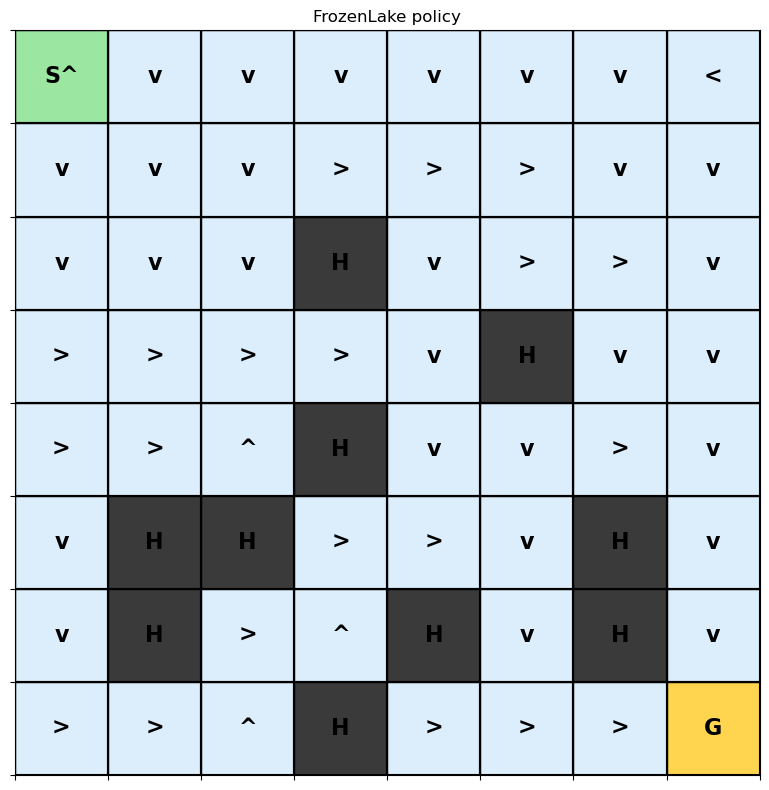

In [424]:
policy = monte_carlo_control_on_policy_without_greedy_epsilon(n_states, transition_probabilities_statewise_actionwise, rewards_state_wise_actionwise)
plot_policy_on_frozen_lake(env, policy)


In [425]:
#Without complete policy evaluation for every policy
def monte_carlo_gpi(n_states, gamma=0.9, max_iterations=2500, max_steps=60):
	#Q= np.zeros((env.observation_space.n, env.action_space.n, 2))
	
	episode_rewards=[]
	epsode_lengths=[]
	policy = np.zeros(n_states, dtype=int)
	Q= monte_carlo_policy_evaluation(policy, 200, 60, gamma)
	for iteration in range(max_iterations):
		initial_random_state = random.randint(0,env.observation_space.n - 1)
		initial_random_action = random.randint(0,env.action_space.n - 1)
		action= initial_random_action
		state= initial_random_state
		env.reset()
		env.unwrapped.s = state
		rewards= []
		states_actions=[]
		flag=0

		for j in range (max_steps):
			states_actions.append([state,action])
			next_state, reward, done, _, _ = env.step(action)
			rewards.append(reward)
			if done:
				flag=1
				epsode_lengths.append(j+1)
				break
			action = policy[next_state]
			state= next_state
		if flag==0:
			epsode_lengths.append(max_steps)
		episode_rewards.append(sum(rewards))
		
		cummulative_reward=0
		states= [row[0] for row in states_actions]
		for j in range(len(rewards)-1,-1,-1):
			cummulative_reward = rewards[j] + cummulative_reward*gamma
			
			if states_actions[j][0] not in states[:j]: 
				Q[states_actions[j][0]][states_actions[j][1]] = cummulative_reward
		new_policy = np.argmax(Q, axis=1)
		policy = new_policy
	return policy, episode_rewards, epsode_lengths

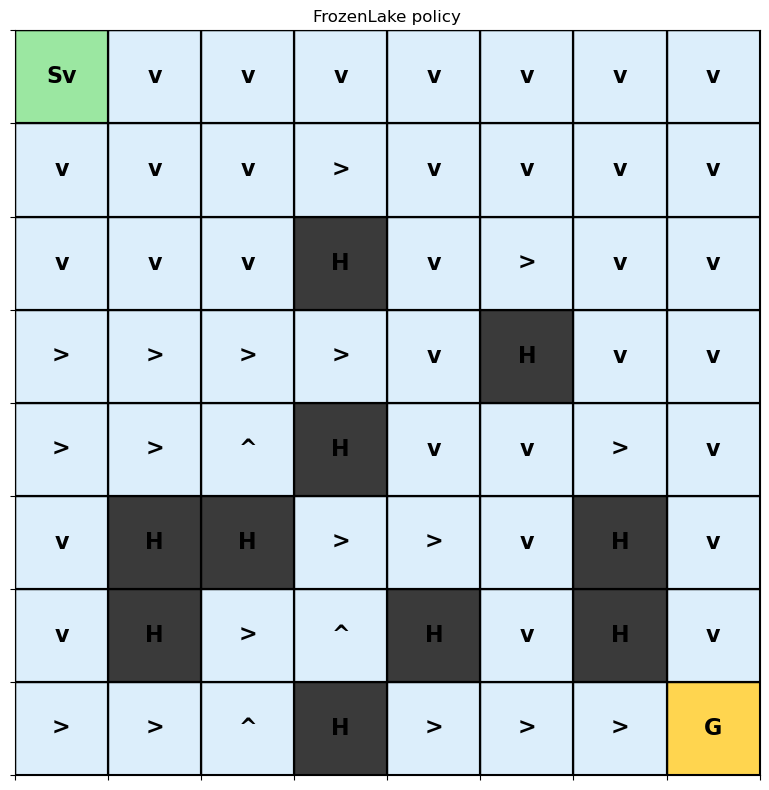

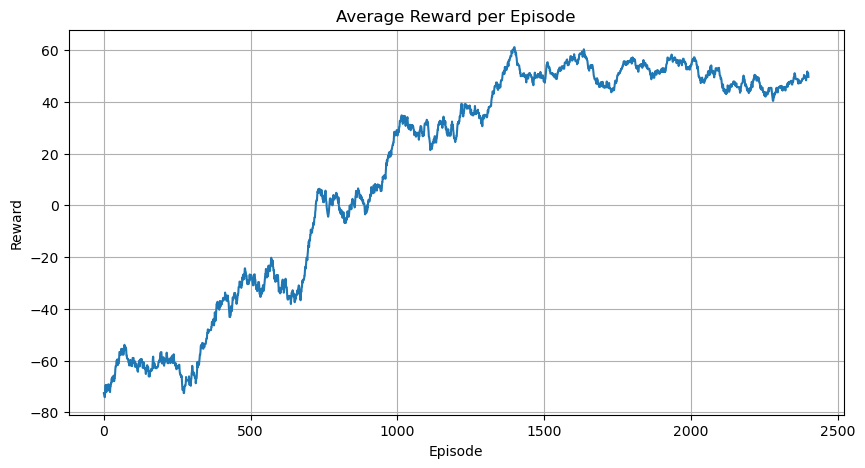

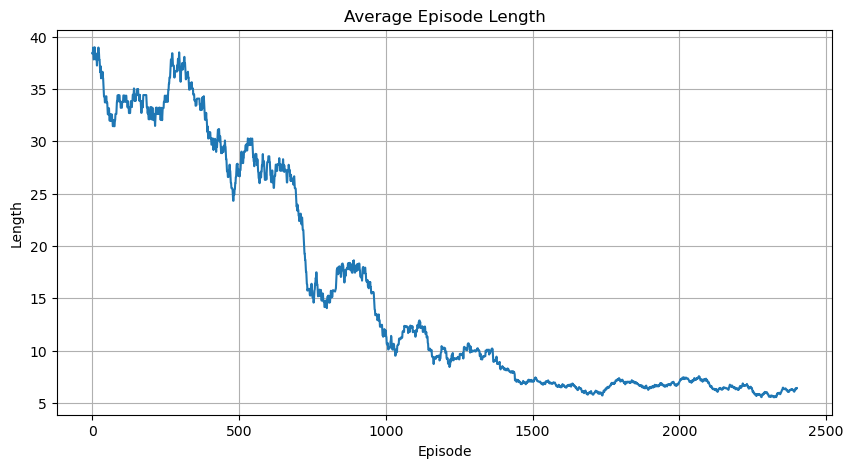

In [426]:
policy, episode_rewards, episode_lengths = monte_carlo_gpi(n_states)
plot_policy_on_frozen_lake(env, policy)
plot_analysis(episode_rewards, episode_lengths)

In [471]:
def monte_carlo_greedy_epsillon(n_states, gamma=0.85, max_iterations=50000, epsilon=0.1, max_steps=50):
	Q= np.zeros((env.observation_space.n, env.action_space.n))
	no_of_times_visited = np.zeros((env.observation_space.n, env.action_space.n))
	
	policy = np.zeros(n_states, dtype=int)
	#Q= monte_carlo_policy_evaluation(policy, 200, 60, gamma)
	epsilon_probabilities = np.random.dirichlet(np.ones(4))
	episode_rewards=[]
	episode_lengths=[]
	
	for iteration in range(max_iterations):
		initial_random_state = random.randint(0,env.observation_space.n - 1)
		state=initial_random_state
		env.reset()
		env.unwrapped.s = state
		rewards= []
		states_actions=[]
		flag=0

		for j in range (max_steps):
			actions=[policy[state]]
			for i in range(4):
				if i not in actions:
					actions.append(i)
			

			action = random.choices(actions, weights=epsilon_probabilities, k=1)[0]
			states_actions.append([state,action])
			next_state, reward, done, _, _ = env.step(action)
			rewards.append(reward)
			if done:
				flag=1
				episode_lengths.append(j+1)
				break
			state= next_state
		
		if flag==0:
			episode_lengths.append(max_steps)
		
		episode_rewards.append(sum(rewards))
		cummulative_reward=0
		states= [row[0] for row in states_actions]
		for j in range(len(rewards)-1,-1,-1):
			cummulative_reward = rewards[j] + cummulative_reward*gamma
			
			if states_actions[j][0] not in states[:j]:
				no_of_times_visited[states_actions[j][0]][states_actions[j][1]]+=1
				Q[states_actions[j][0]][states_actions[j][1]] += (cummulative_reward- Q[states_actions[j][0]][states_actions[j][1]])/(no_of_times_visited[states_actions[j][0]][states_actions[j][1]])
				
				#Q[states_actions[j][0]][states_actions[j][1]] = cummulative_reward
		
		policy = np.argmax(Q, axis=1)
		epsilon_probabilities=[1-epsilon+epsilon/4, epsilon/4, epsilon/4, epsilon/4]
		
	return policy, episode_rewards, episode_lengths


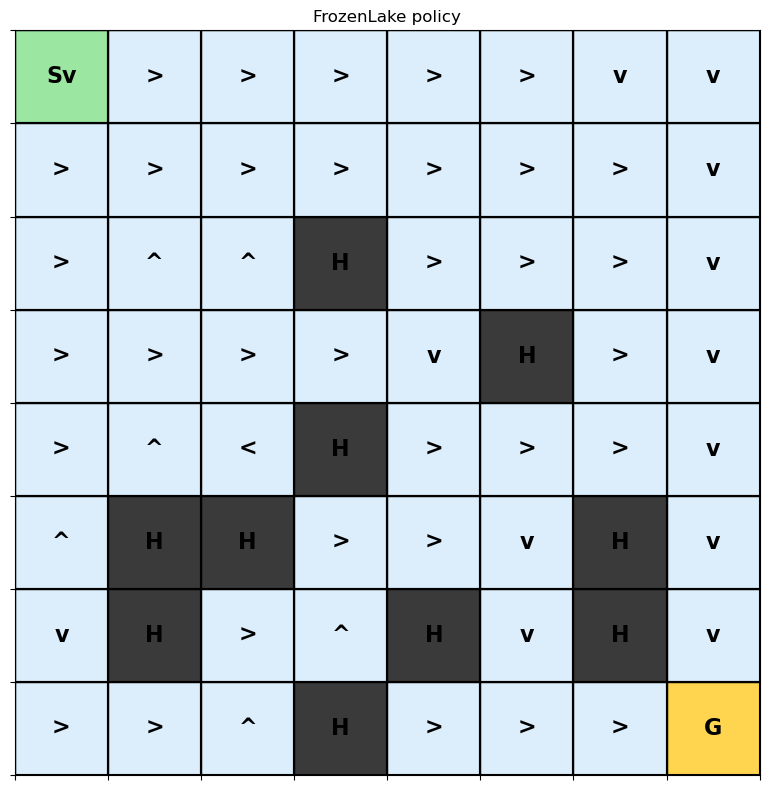

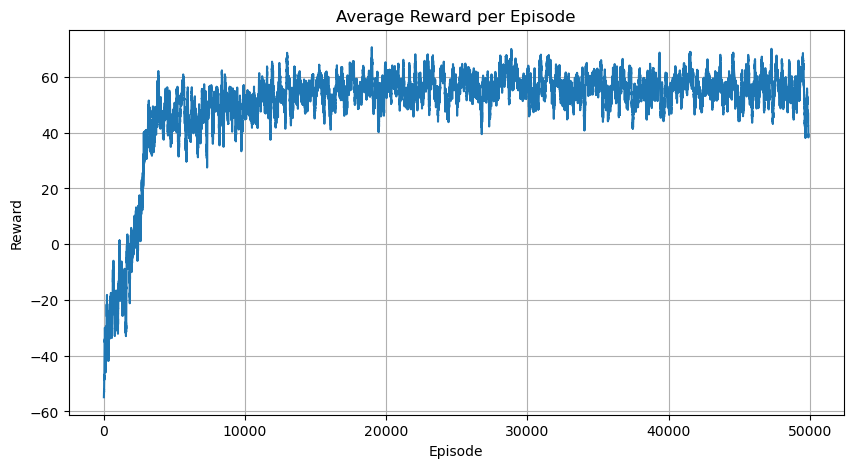

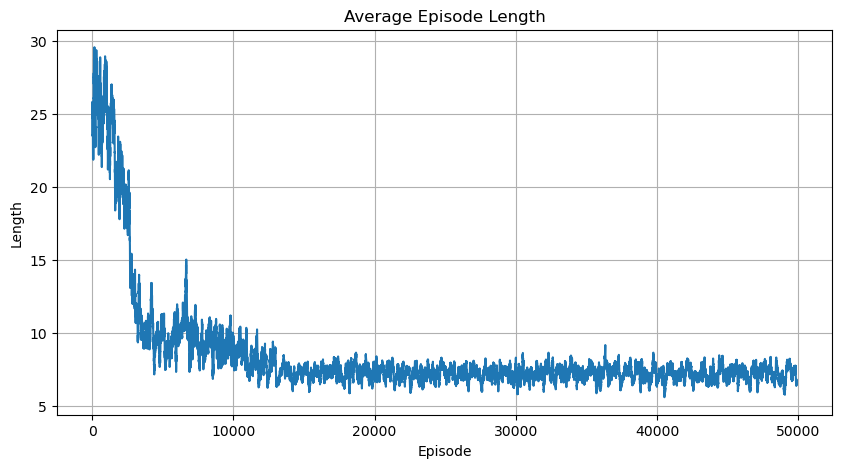

In [472]:
policy, episode_rewards, episode_lengths = monte_carlo_greedy_epsillon(n_states)
plot_policy_on_frozen_lake(env, policy)
plot_analysis(episode_rewards, episode_lengths)

In [503]:
def monte_carlo_off_policy(n_states, gamma=0.8, max_iterations=25000, epsilon=0.1, max_steps=50):
	Q= np.zeros((env.observation_space.n, env.action_space.n))
	no_of_times_visited = np.zeros((env.observation_space.n, env.action_space.n))
	
	policy = np.zeros(n_states, dtype=int)
	#Q= monte_carlo_policy_evaluation(policy, 200, 60, gamma)
	epsilon_probabilities = np.random.dirichlet(np.ones(4))
	episode_lengths=[]
	episode_rewards=[]
	
	for iteration in range(max_iterations):
		initial_random_state = random.randint(0,env.observation_space.n - 1)
		state=initial_random_state
		env.reset()
		env.unwrapped.s = state
		rewards= []
		states_actions=[]
		weight=1
		last_exploration=0
		flag=0
		for j in range (max_steps):
			actions=[policy[state]]
			for i in range(4):
				if i not in actions:
					actions.append(i)
			#print(actions, policy)

			action = random.choices(actions, weights=epsilon_probabilities, k=1)[0]
			if action == actions[0]:
				states_actions.append([state,action,1])
			else:
				states_actions.append([state,action,0])
				last_exploration=j

			next_state, reward, done, _, _ = env.step(action)
			rewards.append(reward)
			if done:
				episode_lengths.append(j+1)
				flag=1
				break
			state= next_state
		if flag==0:
			episode_lengths.append(max_steps)

		cummulative_reward=0
		states= [row[0] for row in states_actions]
		episode_rewards.append(sum(rewards))
		for j in range(len(rewards)-1,-1,-1):
			cummulative_reward = rewards[j] + cummulative_reward*gamma
			if states_actions[j][2] == 1:
				weight *= 1/(1-epsilon+epsilon/4)
				if states_actions[j][0] not in states[last_exploration:j]:
					no_of_times_visited[states_actions[j][0]][states_actions[j][1]]+=1
					Q[states_actions[j][0]][states_actions[j][1]] += weight*(cummulative_reward- Q[states_actions[j][0]][states_actions[j][1]])/(no_of_times_visited[states_actions[j][0]][states_actions[j][1]])
			else:
				no_of_times_visited[states_actions[j][0]][states_actions[j][1]]+=1
				Q[states_actions[j][0]][states_actions[j][1]] += weight*(cummulative_reward- Q[states_actions[j][0]][states_actions[j][1]])/(no_of_times_visited[states_actions[j][0]][states_actions[j][1]])
				break
		
		policy = np.argmax(Q, axis=1)
		epsilon_probabilities=[1-epsilon+epsilon/4, epsilon/4, epsilon/4, epsilon/4]
		
	return policy, episode_rewards, episode_lengths

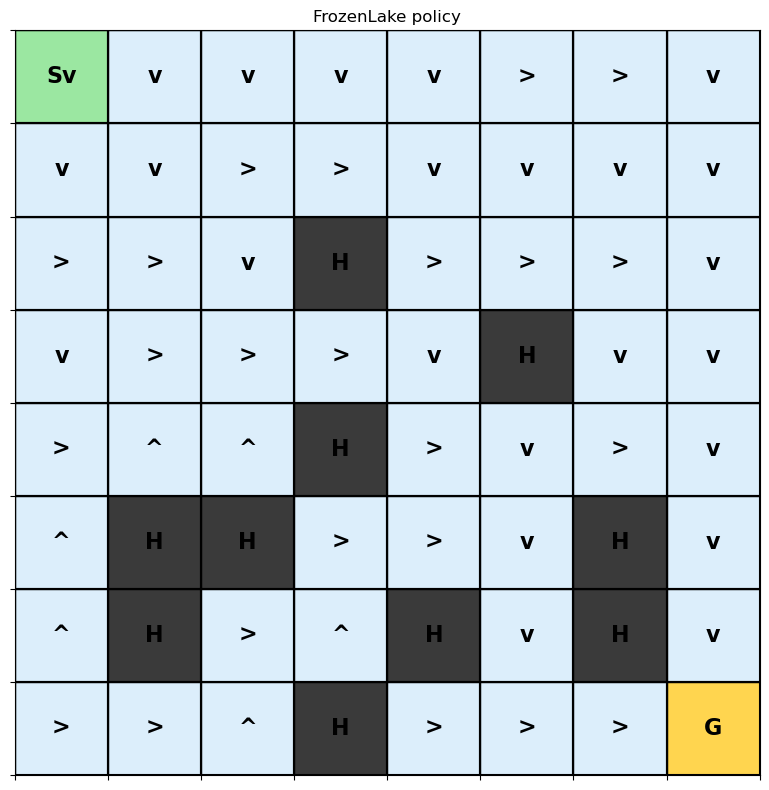

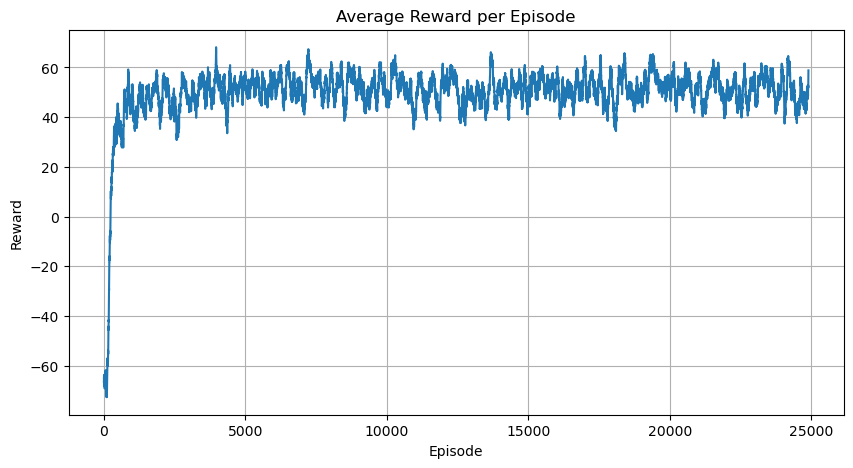

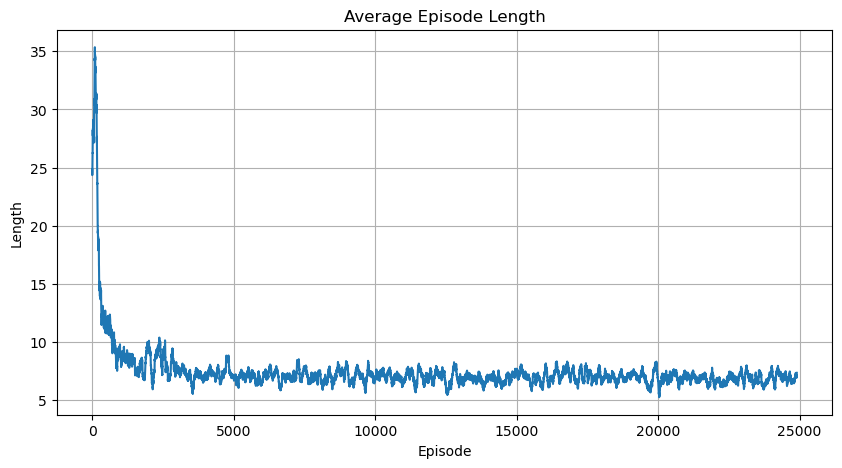

In [504]:
policy, episode_rewards, episode_lengths = monte_carlo_off_policy(n_states)
plot_policy_on_frozen_lake(env, policy)
plot_analysis(episode_rewards, episode_lengths)